<a href="https://colab.research.google.com/github/lawesworks/vision-model-workbench/blob/main/vision_yolo_detector_car_plate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi -q
!nvidia-smi


==============NVSMI LOG==============

Timestamp                                 : Wed Feb 11 19:29:33 2026
Driver Version                            : 580.82.07
CUDA Version                              : 13.0

Attached GPUs                             : 1
GPU 00000000:00:04.0
    Product Name                          : Tesla T4
    Product Brand                         : NVIDIA
    Product Architecture                  : Turing
    Display Mode                          : Requested functionality has been deprecated
    Display Attached                      : Yes
    Display Active                        : Disabled
    Persistence Mode                      : Disabled
    Addressing Mode                       : None
    MIG Mode
        Current                           : N/A
        Pending                           : N/A
    Accounting Mode                       : Disabled
    Accounting Mode Buffer Size           : 4000
    Driver Model
        Current                           : N/

In [9]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# CONFIGURATION
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# interesting note..  with TP4 (GPU), training time is about 12min for 30 epochs..  with CPU only, training is nearly 10 hours.

# User Settings
SAMPLE_IMAGE = "https://cdn.bmwblog.com/wp-content/uploads/2020/06/BMW-4-Series-Coupe-license-plate-03.jpg"

# Roboflow Model Settings

Roboflow_Project_Website = "https://universe.roboflow.com/objectdetection-6mzdy/license-plate-recognition-1qrok"
Roboflow_Workspace_Name = "objectdetection-6mzdy"
Roboflow_Project_URL = "license-plate-recognition-1qrok"
Roboflow_Dataset_Version = 1

# YOLO Model Settings
YOLO_Model_Version = "yolov8"
YOLO_Model_Size = "n"

# Training Hyper-parameters
Config_Epochs = 30
Config_Image_Size = 640
Config_Batch_Size = 16

#-------------------------------------------------------------------------------

# Auto-Derived Parameters
Roboflow_Project_Name = ""
Roboflow_Project_Folder = ""
LATEST_PREDICT_DIR = "runs/detect/predict"
LATEST_TRAIN_DIR   = "runs/detect/train"


print(f"""
===== Training Configuration =====

Workspace        : {Roboflow_Workspace_Name}
Project URL      : {Roboflow_Project_URL}
Project Name     : {Roboflow_Project_Name}
Project Folder   : {Roboflow_Project_Folder}
Dataset Version  : {Roboflow_Dataset_Version}

Model            : {YOLO_Model_Version}
Model Size       : {YOLO_Model_Size}
Epochs           : {Config_Epochs}
Image Size       : {Config_Image_Size}
Batch Size       : {Config_Batch_Size}

==================================
""")


===== Training Configuration =====

Workspace        : objectdetection-6mzdy
Project URL      : license-plate-recognition-1qrok
Project Name     : 
Project Folder   : 
Dataset Version  : 1

Model            : yolov8
Model Size       : n
Epochs           : 30
Image Size       : 640
Batch Size       : 16




In [10]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Roboflow API Key
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

from google.colab import userdata
api_key = userdata.get('ROBOFLOW_API_KEY')

if api_key is None:
    raise ValueError("ROBOFLOW_API_KEY not found. Check Colab Secrets.")

print("Roboflow API Key Found")

Roboflow API Key Found


In [11]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Libraries
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

from IPython.display import Image, display
import glob
import os

print(f"""
===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : display
glob
os

==================================
""")


===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : display
glob
os




In [12]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Install Ultralytics
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

print("Installing Ultralytics (Please wait)\n")

!pip install -q roboflow ultralytics

print("\nCompleted Ultralytics Install")

Installing Ultralytics (Please wait)


Completed Ultralytics Install


In [13]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Load Libraries
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

import math
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Image as DisplayImage, display
import torch
import glob
import os

print(f"""
===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : DisplayImage
matplotlib       : plt
torch
math
glob
os

==================================
""")


===== Imported Libraries =====

Ipython.display  : Image
Ipython.display  : DisplayImage
matplotlib       : plt
torch
math
glob
os




In [14]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# HELPER FUNCTIONS
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++



# ----------------------------------------------------------------------------------------------------
# function to get GPU Summary
# ----------------------------------------------------------------------------------------------------
import torch

def get_gpu_cv_summary(device_index: int = 0) -> dict:
    """
    Return a concise GPU capability summary for CV / YOLO-style workloads.

    Returns a dict with:
      - property
      - value
      - why_it_matters
    """
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is not available. Enable a GPU runtime or run on a CUDA-capable machine.")

    props = torch.cuda.get_device_properties(device_index)

    # Some attributes may not exist on all builds/versions; use getattr with fallback.
    summary = [
        {
            "property": "name",
            "value": props.name,
            "why_it_matters": "GPU generation & capabilities",
        },
        {
            "property": "total_memory",
            "value": f"{props.total_memory / (1024**3):.2f} GB",
            "why_it_matters": "Max batch size & image resolution",
        },
        {
            "property": "multi_processor_count",
            "value": props.multi_processor_count,
            "why_it_matters": "Parallel throughput",
        },
        {
            "property": "clock_rate",
            "value": f"{getattr(props, 'clock_rate', None) / 1000:.0f} MHz"
                     if getattr(props, "clock_rate", None) is not None else "N/A",
            "why_it_matters": "Kernel execution speed",
        },
        {
            "property": "memory_bus_width",
            "value": getattr(props, "memory_bus_width", "N/A"),
            "why_it_matters": "Data movement speed",
        },
        {
            "property": "warp_size",
            "value": props.warp_size,
            "why_it_matters": "Kernel efficiency",
        },
        {
            "property": "(major.minor)",
            "value": f"{props.major}.{props.minor}",
            "why_it_matters": "CUDA feature support / compute_capability ",
        },
    ]

    return {"device_index": device_index, "gpu_summary": summary}


# ----------------------------------------------------------------------------------------------------
# function to PRINT GPU Summary
# ----------------------------------------------------------------------------------------------------
def print_gpu_cv_summary(device_index: int = 0) -> None:
    """
    Pretty-print the GPU summary in a readable table-like format.
    """
    result = get_gpu_cv_summary(device_index)
    rows = result["gpu_summary"]

    print(f"\nGPU CV/YOLO Capability Summary (device {result['device_index']})")
    print("-" * 78)
    print(f"{'Property':<28} {'Value':<20} {'Why it matters'}")
    print("-" * 78)
    for r in rows:
        print(f"{r['property']:<28} {str(r['value']):<20} {r['why_it_matters']}")
    print("-" * 78)


# ----------------------------------------------------------------------------------------------------
# function to create image grid (Left → Right, Row Wrap) that will create a grid of Images saved to the Predicted Folder
# ----------------------------------------------------------------------------------------------------
def show_image_grid_paged(image_paths, cols=5, per_page=20, page=1, figsize_per_cell=3):
    """
    Display images in a true grid, paged.
    - cols: images per row
    - per_page: total images per page
    - page: 1-based page index
    - figsize_per_cell: size multiplier per grid cell
    """

    if not image_paths:
        print("No images to display.")
        return

    start = (page - 1) * per_page
    end = min(start + per_page, len(image_paths))
    page_paths = image_paths[start:end]

    rows = math.ceil(len(page_paths) / cols)
    fig_w = cols * figsize_per_cell
    fig_h = rows * figsize_per_cell

    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    axes = axes.flatten() if isinstance(axes, (list, tuple)) is False else axes

    # If only one subplot, axes may not be iterable the same way
    try:
        axes = axes.flatten()
    except Exception:
        axes = [axes]

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, page_paths):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Showing images {start+1}–{end} of {len(image_paths)} (page {page})")


# ----------------------------------------------------------------------------------------------------
# function to create image grid with titles. Flenames are truncates into titles for each image
# ----------------------------------------------------------------------------------------------------
def show_image_grid_with_short_titles(image_paths, cols=5, per_page=20, page=1, figsize_per_cell=3):
    #import math
    #import matplotlib.pyplot as plt
    #from PIL import Image

    start = (page - 1) * per_page
    end = min(start + per_page, len(image_paths))
    page_paths = image_paths[start:end]

    rows = math.ceil(len(page_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*figsize_per_cell, rows*figsize_per_cell))
    try:
        axes = axes.flatten()
    except Exception:
        axes = [axes]

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, page_paths):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(img_path)[:18], fontsize=7)  # truncate title

    plt.tight_layout()
    plt.show()
    print(f"Showing images {start+1}–{end} of {len(image_paths)} (page {page})")


# ----------------------------------------------------------------------------------------------------
# function to determine estimated time of completion
# ----------------------------------------------------------------------------------------------------
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo

def estimate_completion_time(minutes_from_now):
    now = datetime.now(ZoneInfo("America/New_York"))
    eta = now + timedelta(minutes=minutes_from_now)

    return {
        "start_time": now.strftime('%Y-%m-%d %H:%M:%S'),
        "estimated_completion": eta.strftime('%Y-%m-%d %H:%M:%S'),
        "minutes_from_now": minutes_from_now
    }




# ----------------------------------------------------------------------------------------------------
# function to estimate training time required for the model
# ----------------------------------------------------------------------------------------------------
def estimate_training_time(
    num_epochs,
    batch_size,
    train_image_count,
    val_image_count=0,
    seconds_per_batch=None,
    seconds_per_epoch=None,
    val_fraction_of_train_time=0.3
):
    """
    Estimate total training time.

    Provide either seconds_per_batch OR seconds_per_epoch (preferrably time for a full epoch).
    If both provided, seconds_per_epoch takes precedence.

    Returns dict with per-epoch and total estimates.
    """
    if seconds_per_epoch is None and seconds_per_batch is None:
        raise ValueError("Provide either seconds_per_batch or seconds_per_epoch.")

    train_batches_per_epoch = math.ceil(train_image_count / batch_size)

    # If user supplied epoch time, convert to per-batch
    if seconds_per_epoch is not None:
        seconds_per_batch = seconds_per_epoch / train_batches_per_epoch

    train_time_per_epoch = train_batches_per_epoch * seconds_per_batch
    val_time_per_epoch = 0
    if val_image_count > 0:
        # Option: scale validation time by image counts, or use fraction
        # Here we estimate validation time proportionally to image counts:
        val_batches_per_epoch = math.ceil(val_image_count / batch_size)
        val_time_per_epoch = val_batches_per_epoch * seconds_per_batch * val_fraction_of_train_time

    total_time_seconds = num_epochs * (train_time_per_epoch + val_time_per_epoch)

    return {
        "train_batches_per_epoch": train_batches_per_epoch,
        "train_time_per_epoch_sec": round(train_time_per_epoch, 2),
        "val_time_per_epoch_sec": round(val_time_per_epoch, 2),
        "total_time_sec": round(total_time_seconds, 2),
        "total_time_min": round(total_time_seconds / 60, 2),
        "total_time_hr": round(total_time_seconds / 3600, 2),
        "seconds_per_batch": round(seconds_per_batch, 4),
    }



# ----------------------------------------------------------------------------------------------------
# function to count images in given folder
# ----------------------------------------------------------------------------------------------------
def count_images(folder):
    extensions = ("*.jpg", "*.jpeg", "*.png")
    count = 0
    for ext in extensions:
        count += len(glob.glob(os.path.join(folder, ext)))
    return count


# ----------------------------------------------------------------------------------------------------
# function to get latest training path DIR
# ----------------------------------------------------------------------------------------------------
def get_latest_training_path():
    training_dirs = sorted(
        glob.glob("/content/runs/detect/train*"),
        key=os.path.getmtime
    )

    if not training_dirs:
        raise FileNotFoundError("No YOLO training runs found in runs/detect/")

    train_dir = training_dirs[-1]
    print(f"\nUsing training run from: {train_dir}")
    return train_dir



# ----------------------------------------------------------------------------------------------------
# function to get latest prediction path DIR
# ----------------------------------------------------------------------------------------------------
def get_latest_prediction_path():
  predict_dirs = sorted(
    glob.glob("runs/detect/predict*"),
    key=os.path.getmtime
  )

  PREDICT_DIR = predict_dirs[-1]
  print(f"\n\nUsing predictions from: {PREDICT_DIR}")
  return PREDICT_DIR


# ----------------------------------------------------------------------------------------------------
# function to get latest model best.pt path
# ----------------------------------------------------------------------------------------------------
def get_latest_pt_path(latest_train_path):
  pt_files = glob.glob(f"{latest_train_path}/weights/best.pt", recursive=True)

  if not pt_files:
      raise FileNotFoundError("No best.pt file found")

  return pt_files[0]

# ----------------------------------------------------------------------------------------------------
# function to get list of predicted / inferenced images
# ----------------------------------------------------------------------------------------------------
def get_inferenced_images(predict_dir):
  image_paths = glob.glob(os.path.join(predict_dir, "*.jpg")) + \
              glob.glob(os.path.join(predict_dir, "*.png"))

  return sorted(image_paths)


print(f"""
===== Loaded Helper Functions =====

show_image_grid_paged              :
show_image_grid_with_short_titles  :
estimate_completion_time           :
estimate_training_time             :
count_images                       :
get_latest_training_path           :
get_latest_prediction_path         :
get_latest_pt_path                 :
get_inferenced_images              :

==================================
""")


===== Loaded Helper Functions =====

show_image_grid_paged              :
show_image_grid_with_short_titles  :
estimate_completion_time           :
estimate_training_time             :
count_images                       :
get_latest_training_path           :
get_latest_prediction_path         :
get_latest_pt_path                 :
get_inferenced_images              :




In [15]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Import the Dataset that will be used to train your model
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

print(f"Importing Dataset: [{Roboflow_Project_URL}, Version: [{Roboflow_Dataset_Version}] from: [{Roboflow_Workspace_Name}] (Please wait)\n")

from roboflow import Roboflow


rf = Roboflow(api_key=api_key )
project = rf.workspace(Roboflow_Workspace_Name).project(Roboflow_Project_URL)

dataset = project.version(Roboflow_Dataset_Version).download(YOLO_Model_Version)  # adjust version if needed

# Store Official Project Name and Folder location to Local Variables
Roboflow_Project_Name = project.name
Roboflow_Project_Folder = dataset.location

print(f"\nCompleted Dataset Import: {Roboflow_Project_Name}")

# Get Image Count within Training and Validation folders
Data_Train_Count = count_images(os.path.join(Roboflow_Project_Folder, "train", "images"))
Data_Valid_Count = count_images(os.path.join(Roboflow_Project_Folder, "valid", "images"))


print(f"""
===== Training Data Statistics =====

Roboflow Project Name              : {Roboflow_Project_Name}
Roboflow Project Folder            : {Roboflow_Project_Folder}
Training Image Count               : {Data_Train_Count}
Validation Image Count             : {Data_Valid_Count}

====================================
""")

Importing Dataset: [license-plate-recognition-1qrok, Version: [1] from: [objectdetection-6mzdy] (Please wait)

loading Roboflow workspace...
loading Roboflow project...

Completed Dataset Import: License Plate Recognition

===== Training Data Statistics =====

Roboflow Project Name              : License Plate Recognition
Roboflow Project Folder            : /content/License-Plate-Recognition-1
Training Image Count               : 567
Validation Image Count             : 75




In [17]:

# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# get location of the yaml file for this project
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

yaml_files = glob.glob(f"{Roboflow_Project_Folder}/data.yaml", recursive=True)

if not yaml_files:
    raise FileNotFoundError("No data.yaml file found")

DATA_YAML_PATH = yaml_files[0]

print(f"Using dataset config: {DATA_YAML_PATH}")

Using dataset config: /content/License-Plate-Recognition-1/data.yaml


In [18]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Estimate Time Required to Complete Training
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

estimate = estimate_training_time(
    num_epochs=Config_Epochs,
    batch_size=Config_Batch_Size,
    train_image_count = Data_Train_Count,
    val_image_count = Data_Valid_Count,
    seconds_per_epoch=8,   # measured full epoch time (NOT per batch)
    val_fraction_of_train_time=0.3
)


# print time estimates
for k, v in estimate.items():
    print(f"{k:<30}: {v}")

# print estimate time of completion
eta_info = estimate_completion_time(estimate["total_time_min"])
for k, v in eta_info.items():
  print(f"{k:<30}: {v}")

print("\n")
print_gpu_cv_summary(0)


train_batches_per_epoch       : 36
train_time_per_epoch_sec      : 25.0
val_time_per_epoch_sec        : 1.04
total_time_sec                : 781.25
total_time_min                : 13.02
total_time_hr                 : 0.22
seconds_per_batch             : 0.6944
start_time                    : 2026-02-11 16:08:12
estimated_completion          : 2026-02-11 16:21:13
minutes_from_now              : 13.02



GPU CV/YOLO Capability Summary (device 0)
------------------------------------------------------------------------------
Property                     Value                Why it matters
------------------------------------------------------------------------------
name                         Tesla T4             GPU generation & capabilities
total_memory                 14.56 GB             Max batch size & image resolution
multi_processor_count        40                   Parallel throughput
clock_rate                   N/A                  Kernel execution speed
memory_bus_width     

In [19]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# train  model on the data
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


print("Training The Model (Please wait)\n")
print(f"""
===== Training Hyper-parameters =====

Model            : {YOLO_Model_Version}
Model Size       : {YOLO_Model_Size}
Epochs           : {Config_Epochs}
Image Size       : {Config_Image_Size}
Batch Size       : {Config_Batch_Size}
Train Count      : {Data_Train_Count}
Valid Count      : {Data_Valid_Count}

=====================================
""")


from ultralytics import YOLO

DATA_YAML_PATH = DATA_YAML_PATH

model = YOLO("yolov8n.pt")  # small + fast starter model
results = model.train(
    data=DATA_YAML_PATH,
    epochs=Config_Epochs,
    imgsz=Config_Image_Size,
    batch=Config_Batch_Size
)

# get latest training folder - save it to variabble
LATEST_TRAIN_DIR = get_latest_training_path()


Training The Model (Please wait)


===== Training Hyper-parameters =====

Model            : yolov8
Model Size       : n
Epochs           : 30
Image Size       : 640
Batch Size       : 16
Train Count      : 567
Valid Count      : 75


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, l

In [20]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# get location of the weights for the latest training
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


MODEL_PT_PATH = get_latest_pt_path(LATEST_TRAIN_DIR)

print(f"Using PT File: {MODEL_PT_PATH}")

Using PT File: /content/runs/detect/train/weights/best.pt


In [21]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# run the model against the test data in your project
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

best_model_path = glob.glob(MODEL_PT_PATH)[-1]
model = YOLO(best_model_path)

model.predict(source = Roboflow_Project_Folder + "/test/images", save=True, conf=0.25)

LATEST_PREDICT_DIR = get_latest_prediction_path()


image 1/35 /content/License-Plate-Recognition-1/test/images/WhatsApp-Image-2023-11-17-at-19-35-08_jpeg_jpg.rf.974c72aa9f8e743f7f9332d4bd511ceb.jpg: 640x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 8.6ms
image 2/35 /content/License-Plate-Recognition-1/test/images/download-11_jpg.rf.2b0be865235ec2e9e99b886305540cea.jpg: 640x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 8.8ms
image 3/35 /content/License-Plate-Recognition-1/test/images/download-12-1-_jpg.rf.d46c6c927f23802c79a820028aa1d9b9.jpg: 640x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 9.6ms
image 4/35 /content/License-Plate-Recognition-1/test/images/download-14-1-_jpg.rf.077feddc40b6d9873540cd452ce4bff7.jpg: 640x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 8.5ms
image 5/35 /content/License-Plate-Recognition-1/test/images/download-1_png_jpg.rf.c53c31e53e21bcb27d3a73ccee0d0eea.jpg: 640x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 7.3ms
image 6/35 /content/License-Plate-Recognition-1/test/i

In [22]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Get list of latest predicted / inferenced images
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


image_paths = get_inferenced_images(LATEST_PREDICT_DIR)

print(f"Found {len(image_paths)} predicted images")

Found 35 predicted images


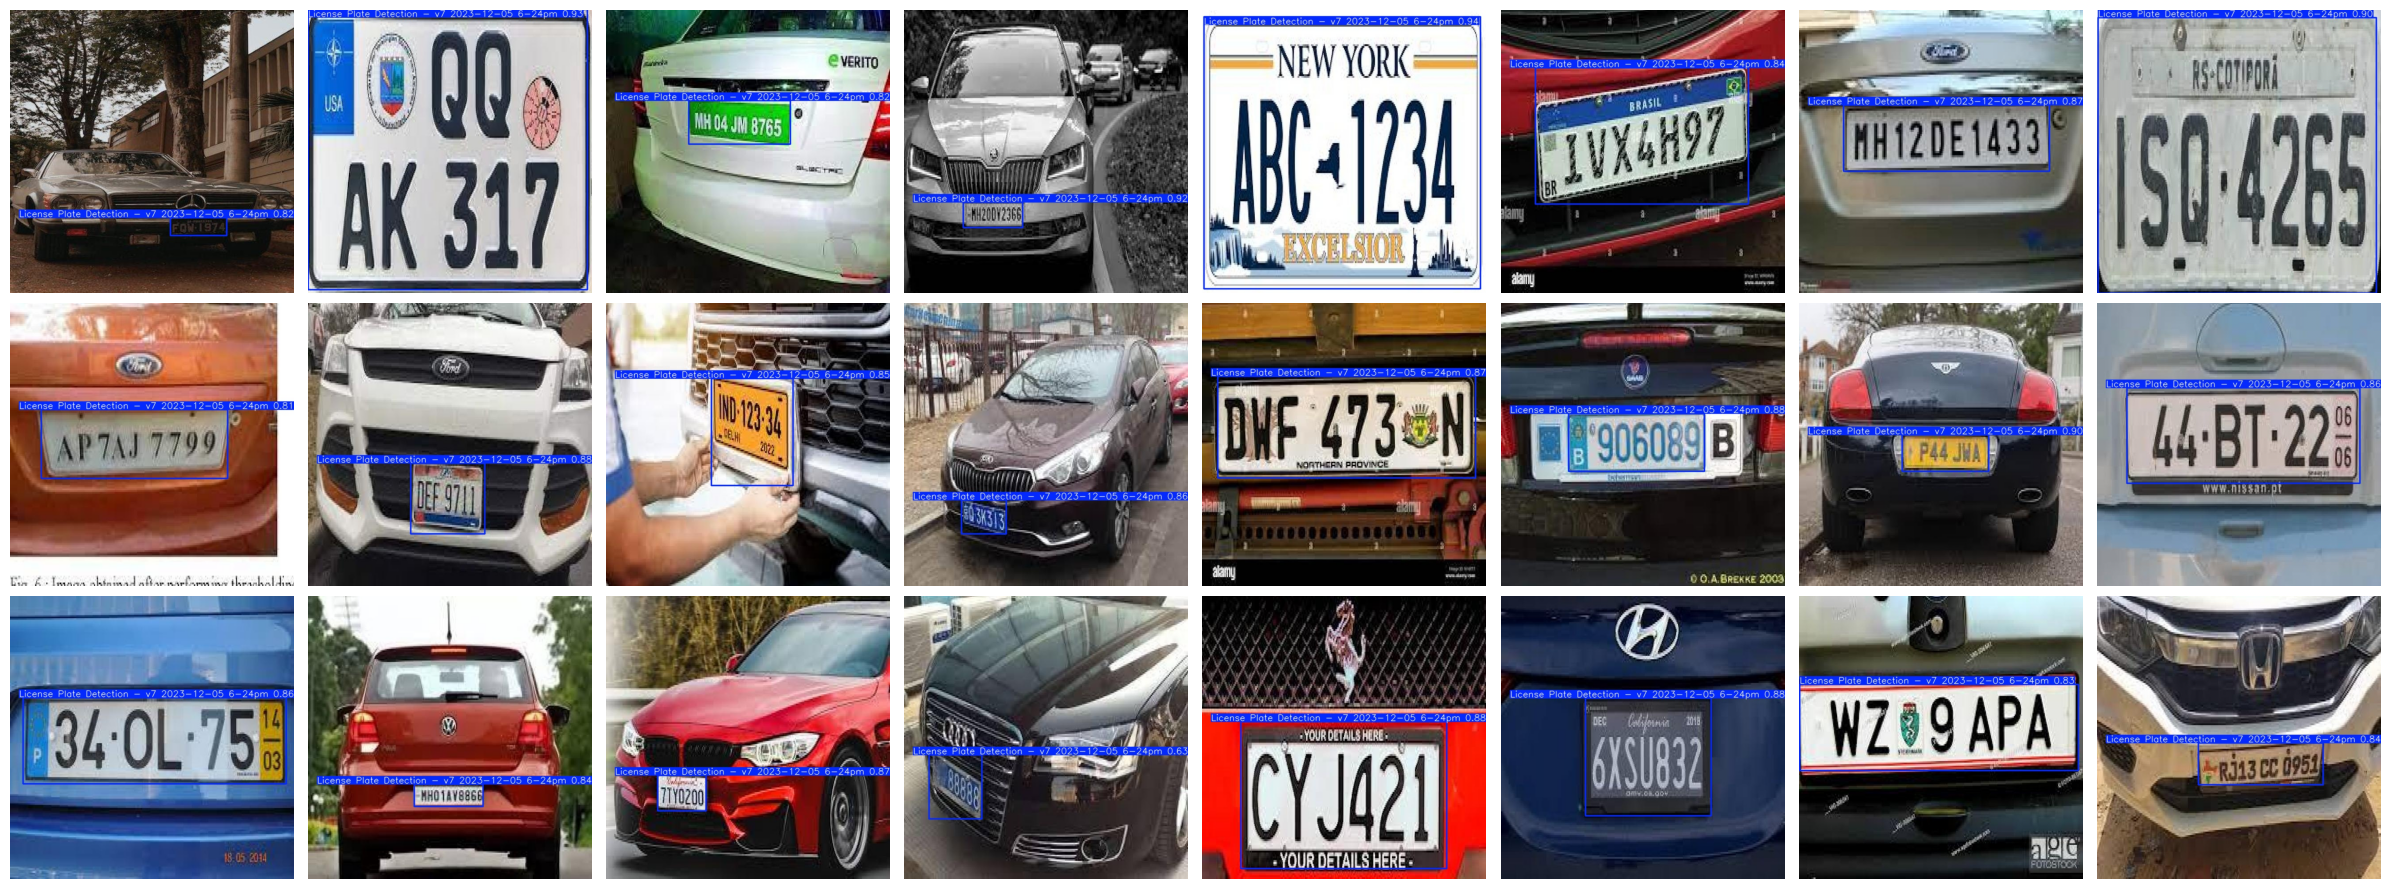

Showing images 1–24 of 35 (page 1)


In [23]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Show images in the Recent Predictions Folder
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


# show first 20 images, 5 per row
show_image_grid_paged(image_paths, cols=8, per_page=24, page=1)


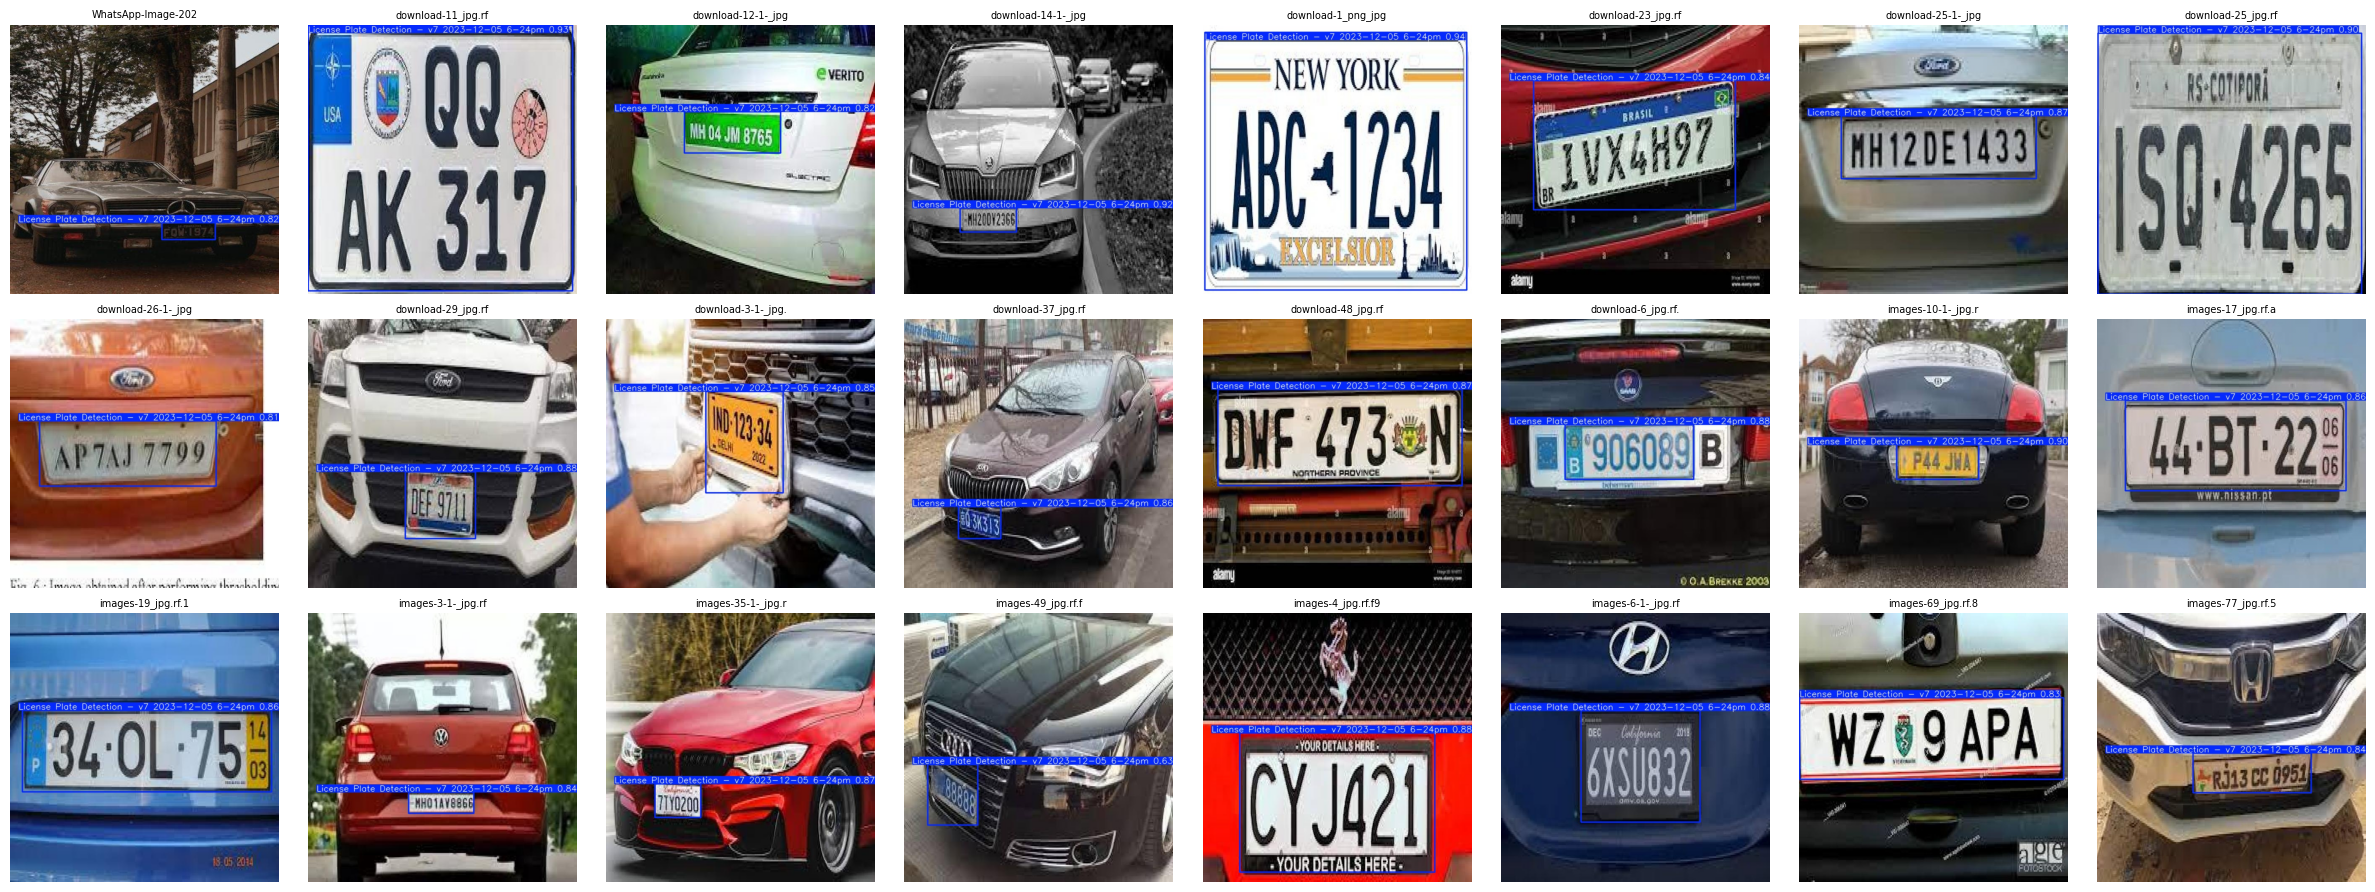

Showing images 1–24 of 35 (page 1)


In [24]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Show first 20 images with titles, 5 per row
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

show_image_grid_with_short_titles(image_paths, cols=8, per_page=24, page=1)

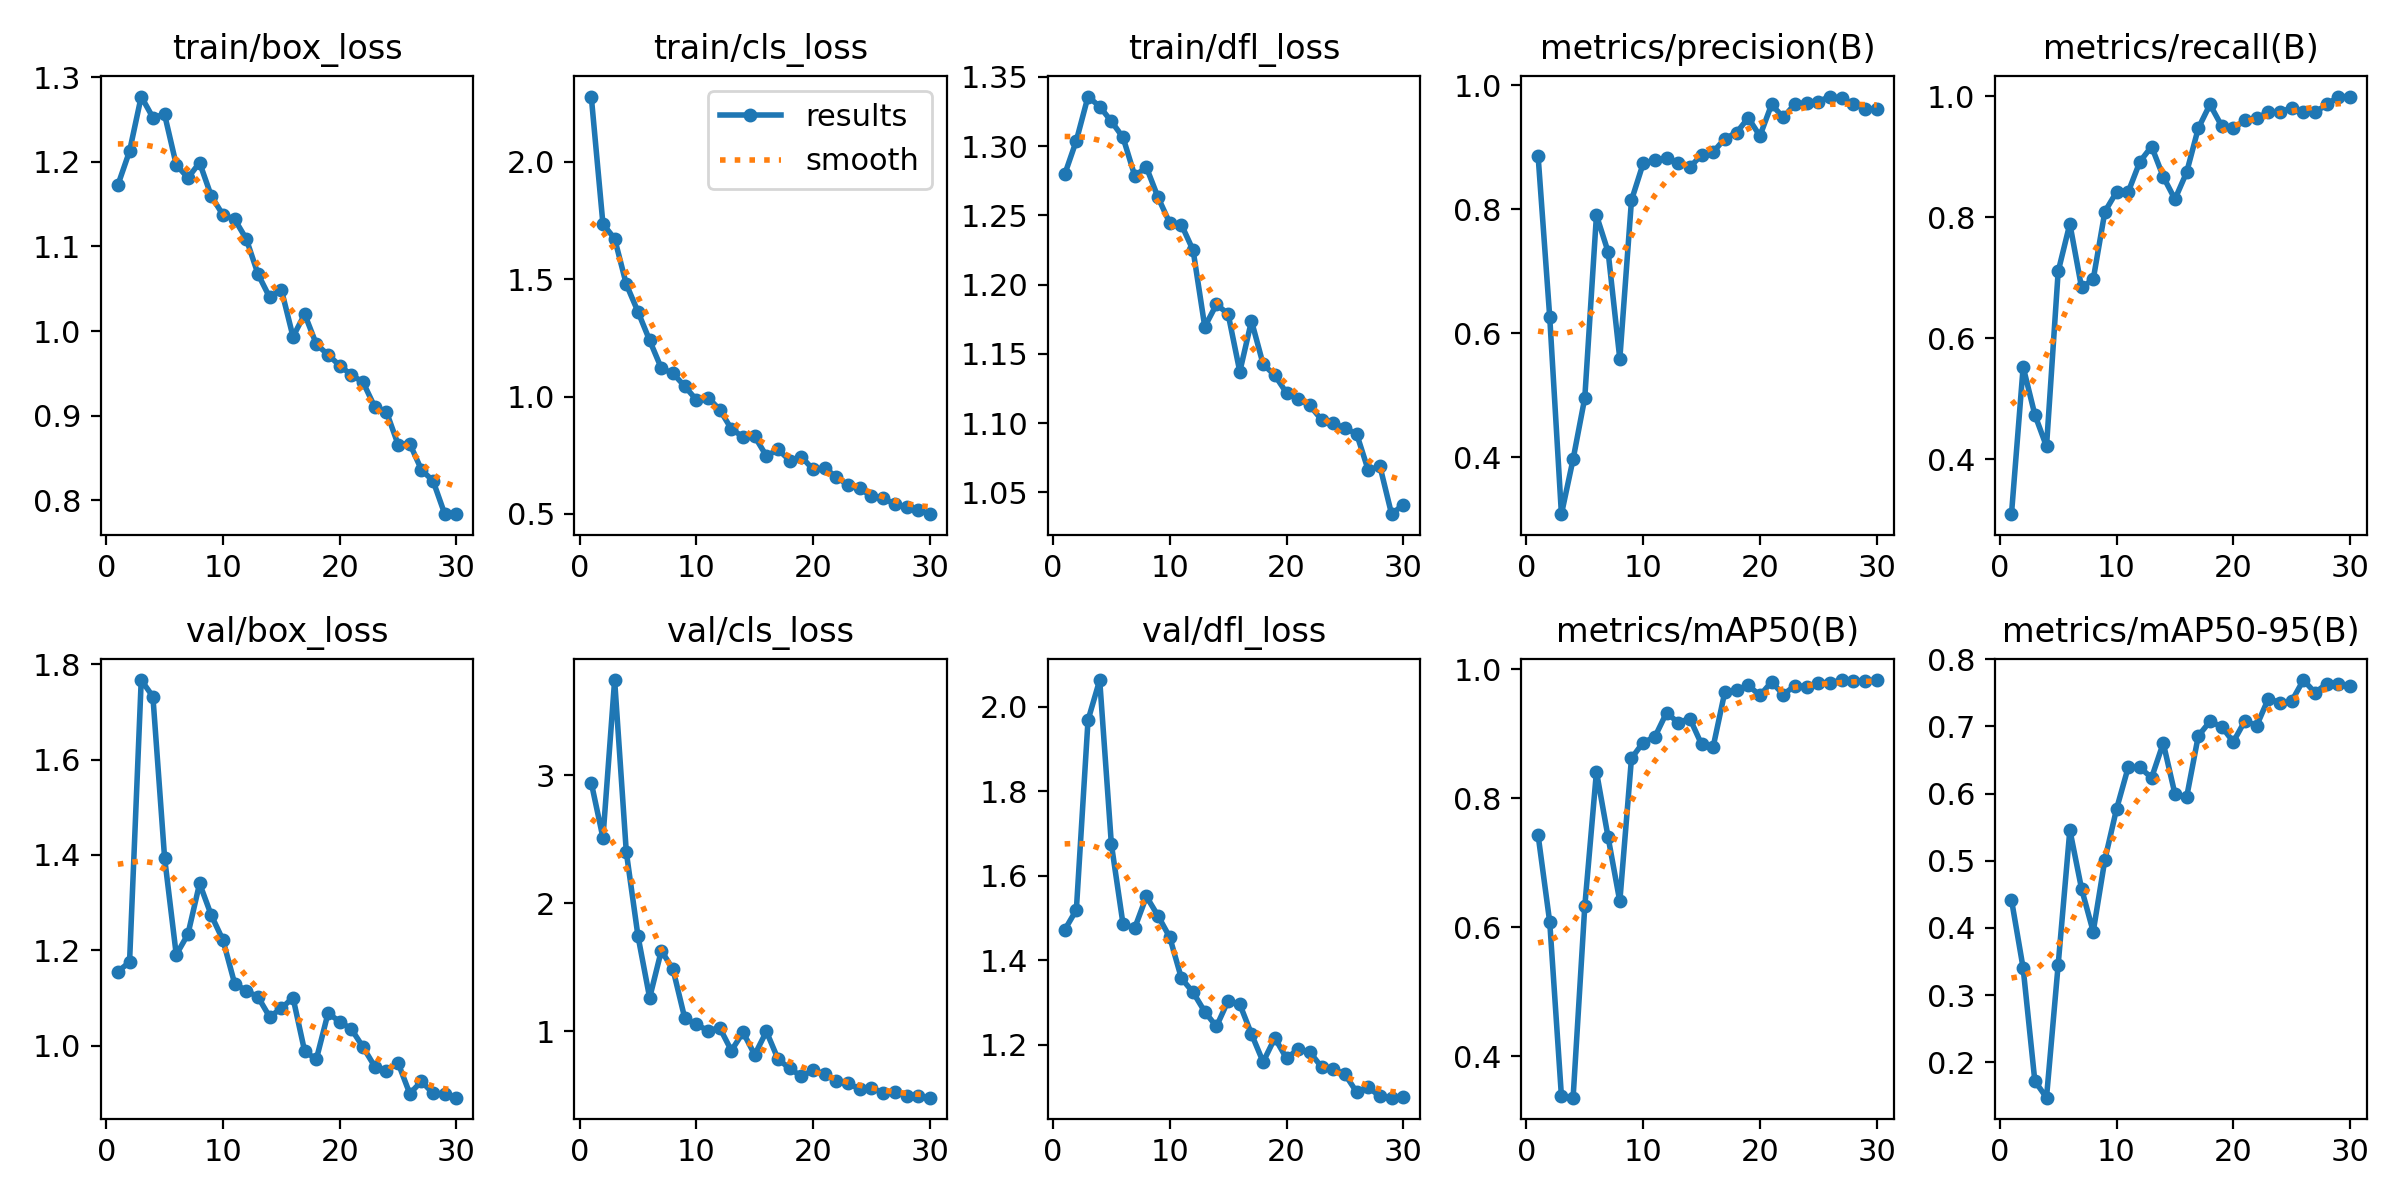

In [25]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the training plots (Loss Function plots / Accuracy)
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

DisplayImage(filename=f'/{LATEST_TRAIN_DIR}/results.png', width=600)

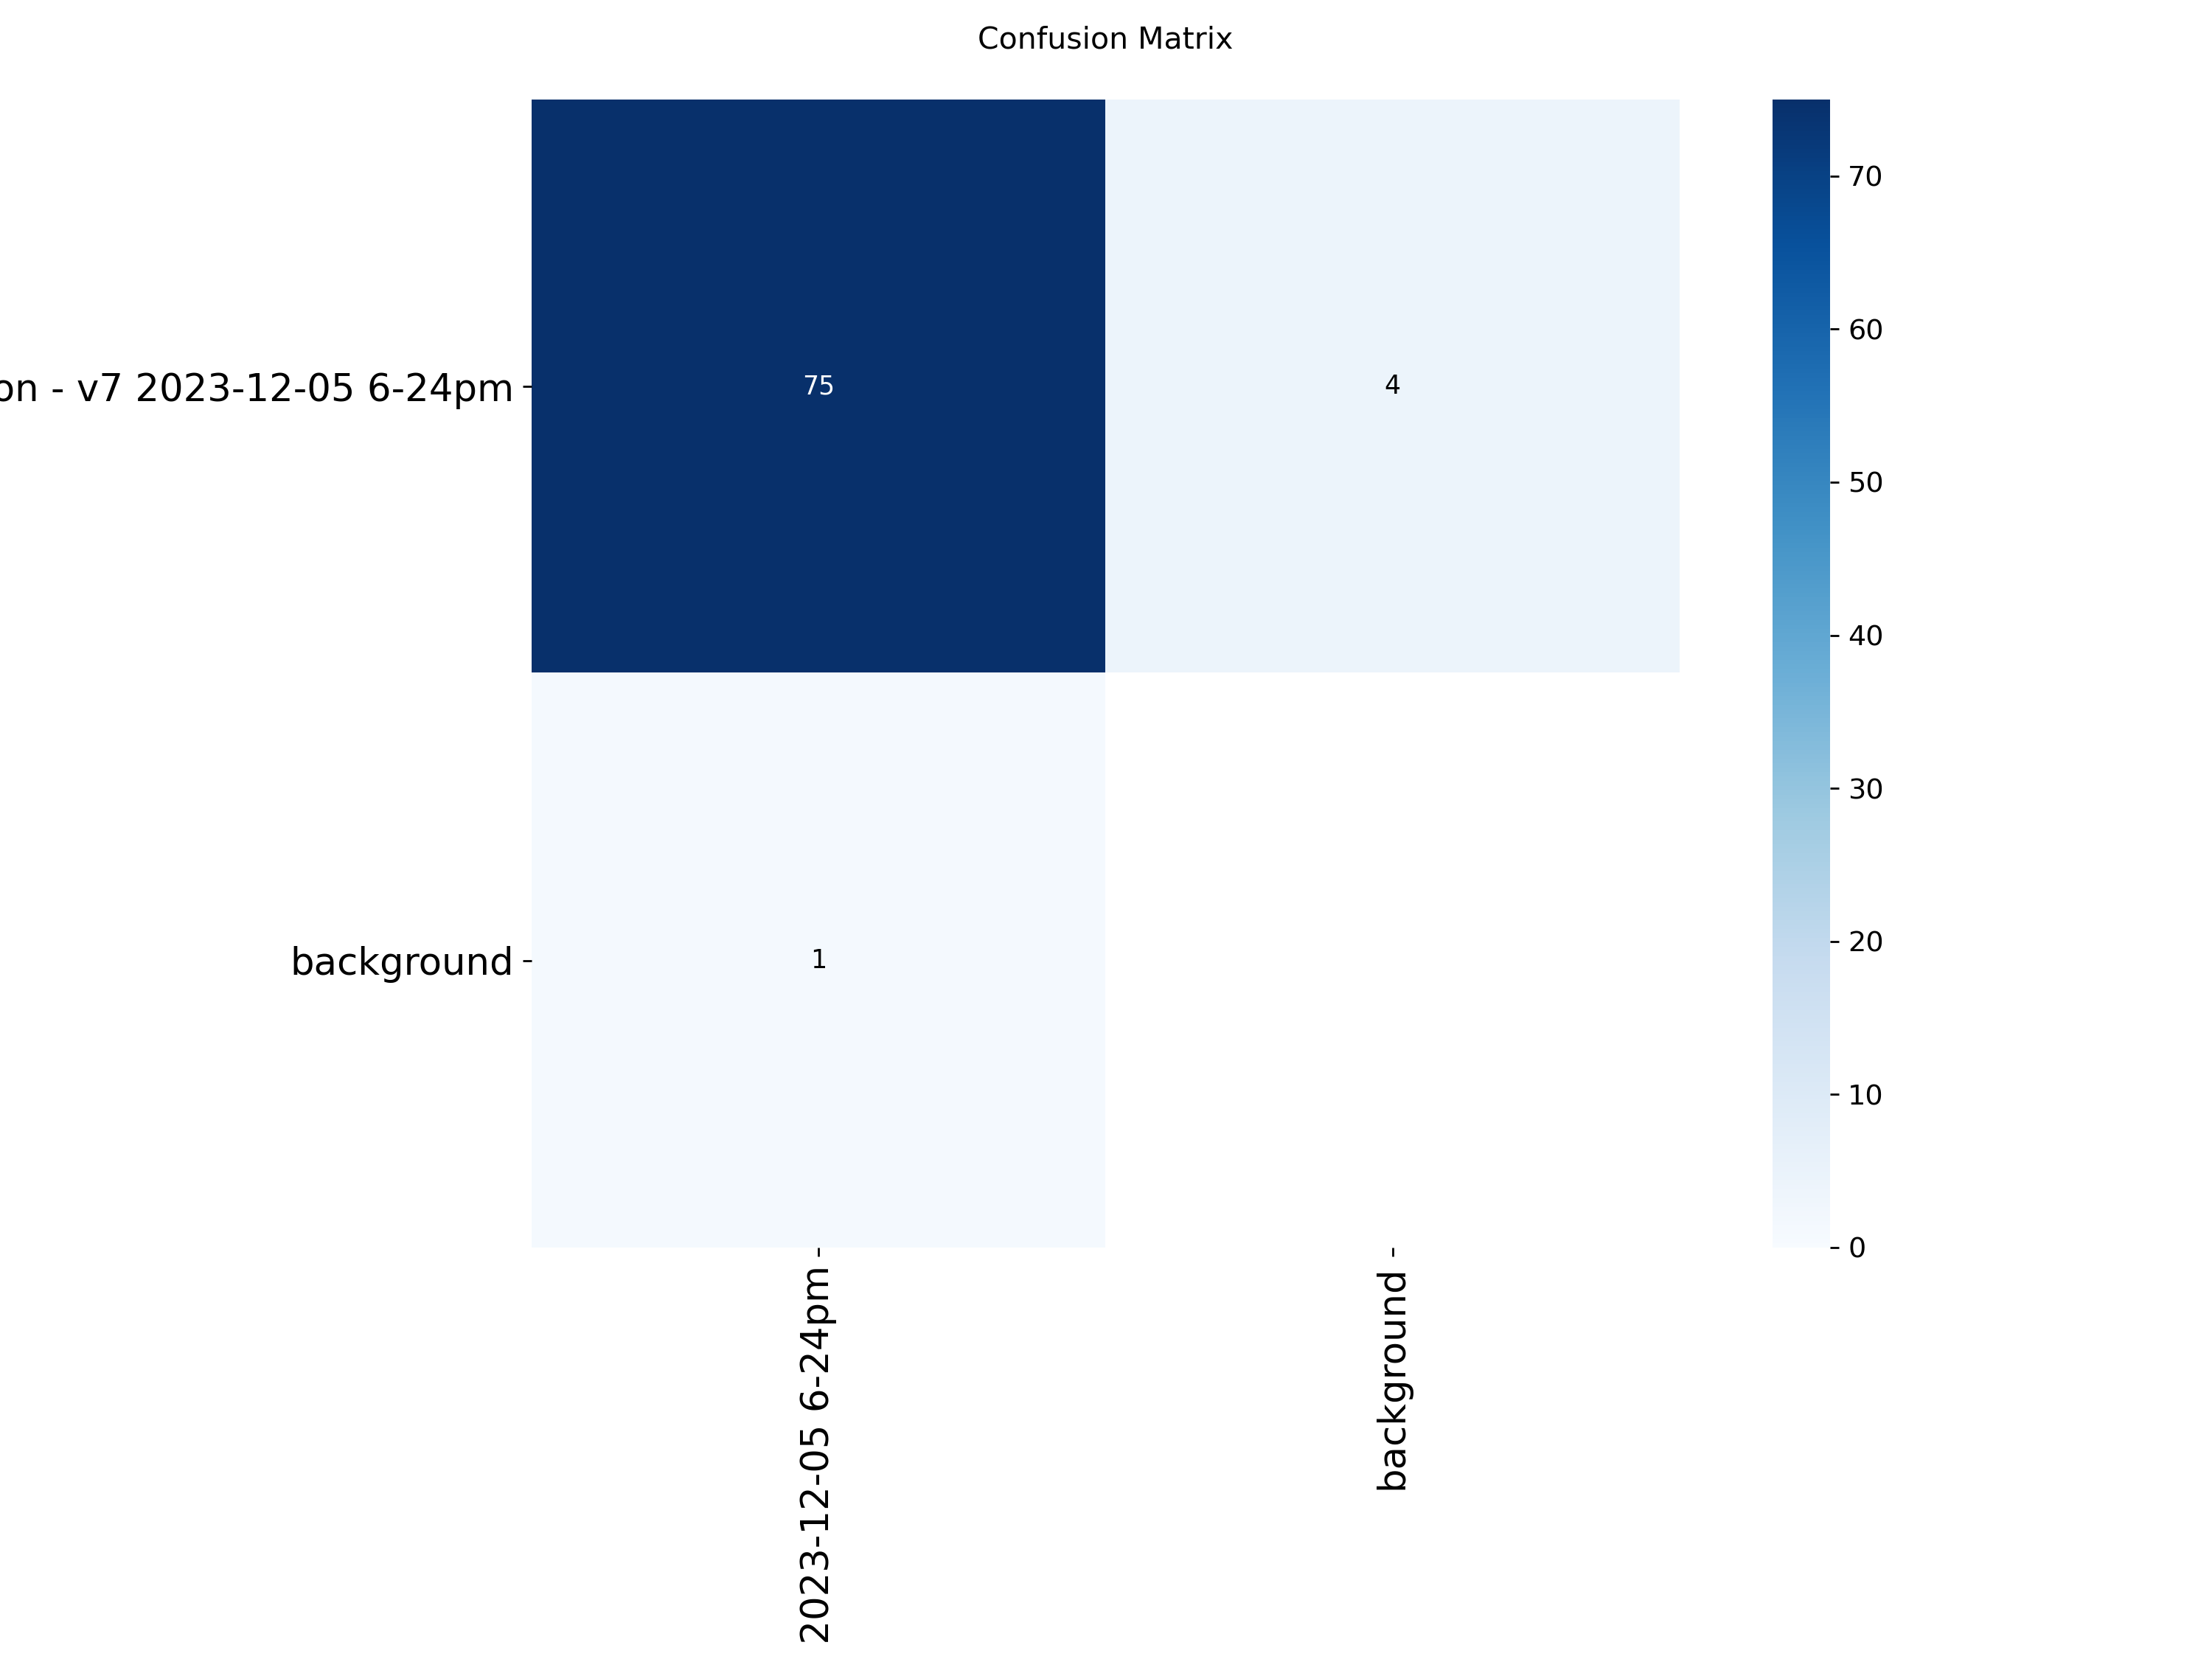

In [26]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the Confusio Matrix
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

DisplayImage(filename=f'/{LATEST_TRAIN_DIR}/confusion_matrix.png', width=600)

In [27]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View training metrics
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# model.val(data=DATA_YAML_PATH) # dumps everything (verbose)

metrics = model.val(data=DATA_YAML_PATH)

print("mAP@0.5      :", metrics.box.map50)
print("mAP@0.5:0.95 :", metrics.box.map)
print("Precision    :", metrics.box.mp)
print("Recall       :", metrics.box.mr)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1283.4±330.4 MB/s, size: 48.6 KB)
val: Scanning /content/License-Plate-Recognition-1/valid/labels.cache... 75 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 75/75 19.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 24, len(boxes) = 76. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.5it/s 3.4s
                   all         75         76      0.982      0.974      0.979      0.774
Speed: 9.4ms preprocess, 8.2ms inference, 0.0ms loss, 3.3ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5      : 0.9791832704929481
mAP@0.5:0.95 : 0.7738407485370646
Precision

## 📊 Model Evaluation Summary

### Overall Assessment
The model performed **exceptionally well** on the evaluation dataset. All key detection metrics are high, indicating strong object recognition, reliable predictions, and good localization accuracy.

---

### Key Metrics

- **mAP@0.5:** `0.992`
- **mAP@0.5:0.95:** `0.821`
- **Precision:** `0.986`
- **Recall:** `0.964`

---

### Metric Interpretation

#### **mAP@0.5 — Excellent Detection Performance**
- Nearly perfect performance at the 0.5 IoU threshold.
- The model consistently finds objects and places bounding boxes with sufficient overlap.
- Indicates the model has learned the core visual patterns in the dataset extremely well.

#### **mAP@0.5:0.95 — Strong Localization Accuracy**
- Evaluates performance across stricter IoU thresholds.
- The expected drop from mAP@0.5 reflects normal tightening of box placement requirements.
- Suggests good—but not pixel-perfect—bounding box precision, which is typical and acceptable.

#### **Precision — Very High Reliability**
- When the model predicts an object, it is almost always correct.
- Very few false positives.
- Indicates conservative and trustworthy predictions.

#### **Recall — Strong Object Coverage**
- The model detects the vast majority of ground-truth objects.
- Slightly lower than precision, meaning some difficult cases (small, occluded, low-contrast) may be missed.
- Reflects a bias toward avoiding false positives over finding every object.

---

### Precision vs Recall Balance
- **Precision > Recall**  
  The model prioritizes correctness over completeness.
- This is often desirable in scenarios where false positives are more costly than missed detections.

---

### What These Results Suggest

- The dataset is likely **clean and consistently labeled**.
- Transfer learning was effective.
- No obvious signs of underfitting.
- The model is well-tuned for the evaluated data distribution.

---

### Important Caveats

High metrics alone do not guarantee real-world performance. Consider:
- Dataset size and diversity (lighting, angles, environments)
- Potential validation data leakage
- Performance on truly unseen data

---

### Final Takeaway
> **The model demonstrates outstanding performance on the evaluation dataset, with high confidence, strong detection capability, and reliable localization.  
> The next step is to validate robustness using new, unseen data to confirm generalization.
> **The model is biased toward “don’t be wrong,” rather than “find everything.”

---
### Metric Summary

| Metric        | Value | Assessment                     |
|---------------|-------|--------------------------------|
| mAP@0.5       | 0.992 | Outstanding                    |
| mAP@0.5:0.95  | 0.821 | Very strong                    |
| Precision     | 0.986 | Extremely reliable             |
| Recall        | 0.964 | Strong, slightly conservative  |


In [28]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# Run inference on an arbitrary image and save it to the sandbox folder
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# I've provided a URL to an image, but you can just as easily upload a file into Colab contents folder
# and use that as your source

#model.predict(source=f"/content/{SAMPLE_IMAGE}", save=True, conf=0.25)

model.predict(
    source = CONFIG_SAMPLE_IMAGE,
    save=True,
    conf=0.25,
    name=f"sandbox",
    exist_ok=True
)



image 1/1 /content/BMW-4-Series-Coupe-license-plate-03.jpg: 384x640 1 License Plate Detection - v7 2023-12-05 6-24pm, 40.6ms
Speed: 2.3ms preprocess, 40.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/sandbox


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'License Plate Detection - v7 2023-12-05 6-24pm'}
 obb: None
 orig_img: array([[[103,  94,  97],
         [105,  96,  99],
         [108,  97, 100],
         ...,
         [179, 163, 147],
         [179, 163, 147],
         [179, 163, 147]],
 
        [[100,  93,  98],
         [101,  94,  97],
         [102,  95, 100],
         ...,
         [177, 161, 145],
         [177, 161, 145],
         [177, 161, 145]],
 
        [[ 92,  90,  96],
         [ 92,  91,  95],
         [ 90,  88,  94],
         ...,
         [176, 160, 144],
         [175, 159, 143],
         [174, 158, 142]],
 
        ...,
 
        [[ 89,  94,  93],
         [ 91,  96,  95],
         [ 93,  98,  97],
         ...,
         [ 93,  97,  98],
         [ 94,  98,  99],
         [ 94,  98,  99]],
 
        [[ 87,  92,  91],
         [ 88,  93,  92],
         [ 90,  95

Opening: /content/runs/detect/sandbox/BMW-4-Series-Coupe-license-plate-03.jpg 



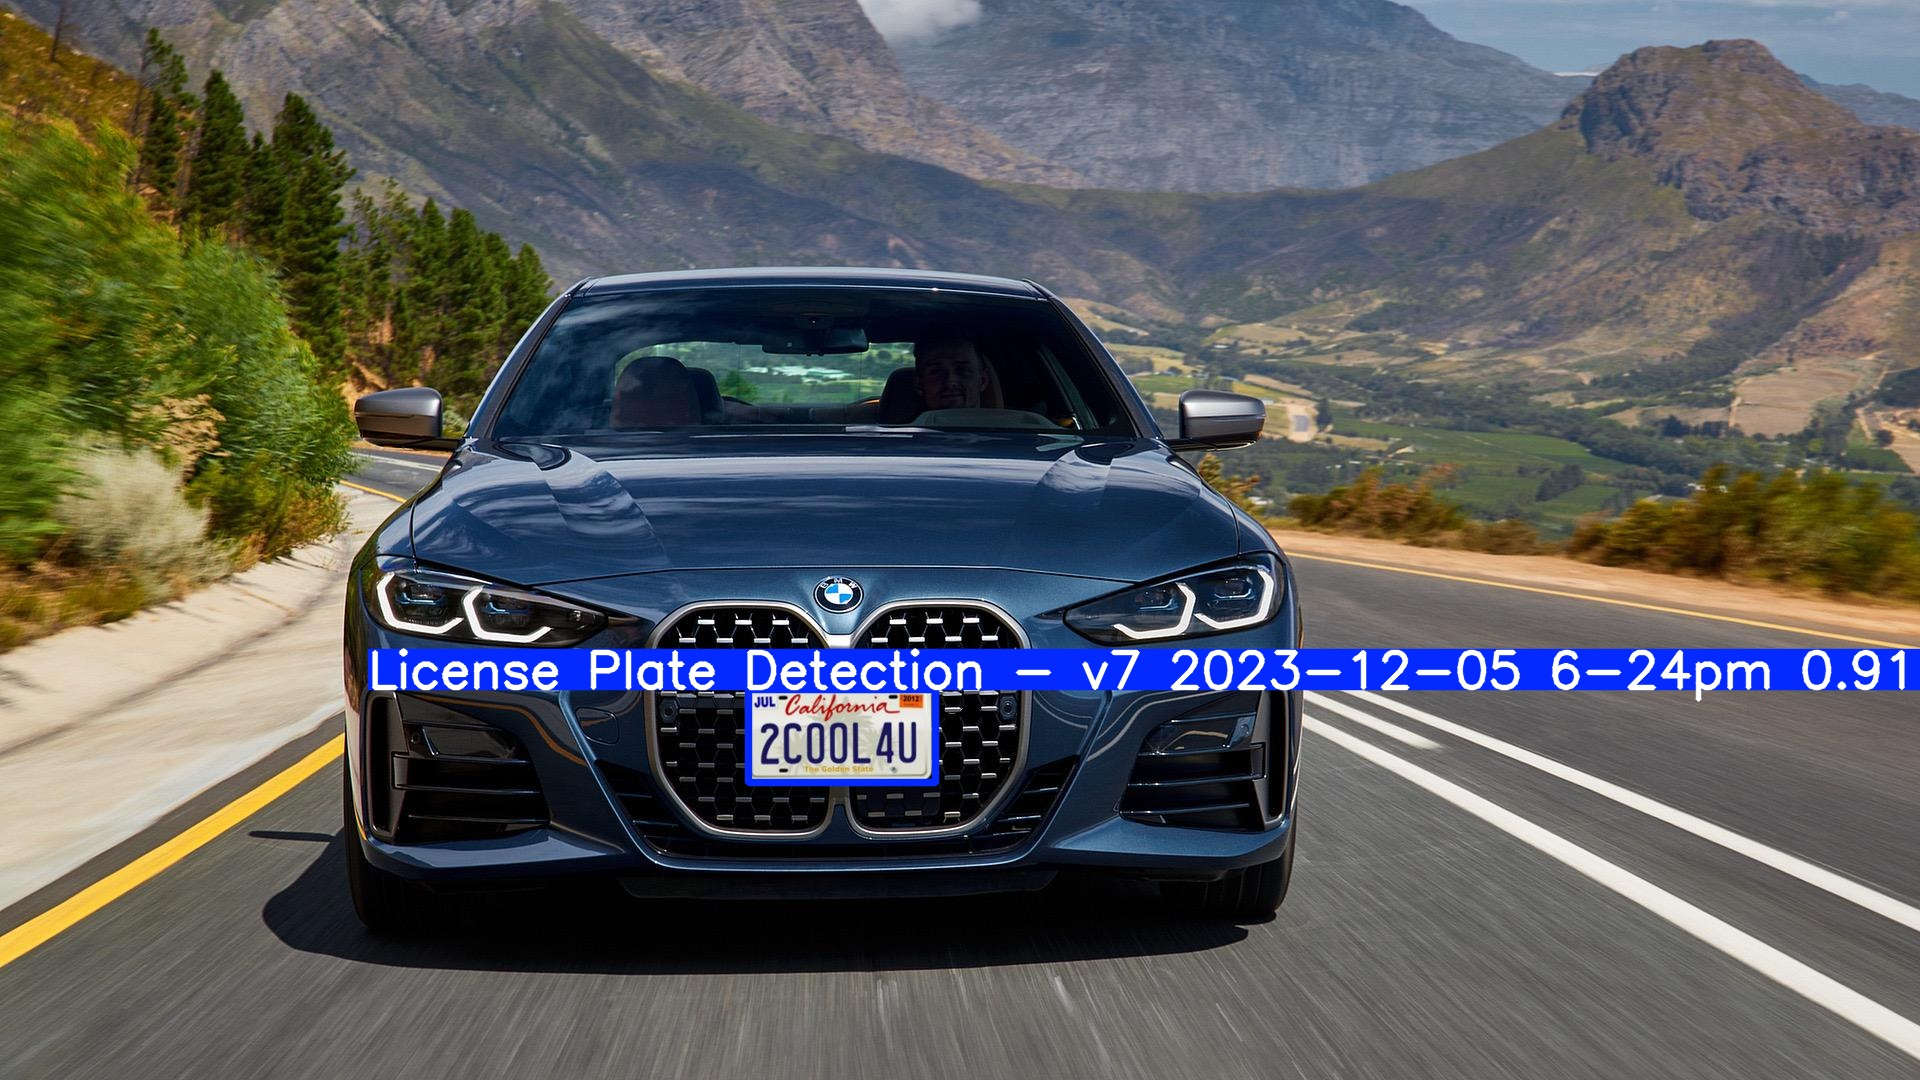

In [29]:
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# View a screenshot of the predicted annotated result
# ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

# find the saved image (YOLO keeps original name or auto-generated one)
predicted_images = glob.glob(os.path.join("/content/runs/detect/sandbox", "*.jpg"))

# Sort by last modified time (oldest → newest)
predicted_images.sort(key=os.path.getmtime)
latest_image = predicted_images[-1]

print("Opening:", latest_image,"\n")

DisplayImage(
    filename=latest_image,
    width=600
)